In [1]:
!pip install -q diffusers transformers accelerate controlnet_aux gradio torch

print("Required libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.9/322.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import torch
from diffusers import StableDiffusionControlNetImg2ImgPipeline, ControlNetModel, UniPCMultistepScheduler
from diffusers.utils import load_image
import time
import gc
import os

# --- Configuration ---
base_model_id = "runwayml/stable-diffusion-v1-5"
controlnet_id = "lllyasviel/sd-controlnet-openpose"

# --- Load ControlNet Model ---
print("Loading ControlNet model (OpenPose)...")
start_time_cn = time.time()
controlnet_openpose = None
try:
    controlnet_openpose = ControlNetModel.from_pretrained(
        controlnet_id,
        torch_dtype=torch.float16
    )
    print(f"ControlNet (OpenPose) loaded successfully in {time.time() - start_time_cn:.2f} seconds.")
except Exception as e:
    print(f"Error loading ControlNet ({controlnet_id}): {e}")
    controlnet_openpose = None

# --- Load the Main Pipeline with Base Model ---
pipe = None
if controlnet_openpose:
    print(f"\nAttempting to load main pipeline with base model: {base_model_id}...")
    start_time_pipe = time.time()
    try:
        pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
            base_model_id,
            controlnet=controlnet_openpose, # Pass the loaded OpenPose ControlNet
            torch_dtype=torch.float16,
            safety_checker=None,
        )
        pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
        print("Pipeline components loaded initially.")

        # --- DISABLE SEQUENTIAL CPU OFFLOADING ---
        # print("Enabling Sequential Model CPU Offloading (will be VERY slow)...")
        # pipe.enable_sequential_cpu_offload()
        # print("Sequential Model CPU Offloading enabled.")

        print("Moving main generation pipeline to cuda:0...")
        pipe.to('cuda:0')
        print("Main pipeline moved to cuda:0.")

        print(f"Pipeline loaded and configured successfully in {time.time() - start_time_pipe:.2f} seconds.")

    except Exception as e:
        print(f"Error loading pipeline or moving to GPU: {e}")
        pipe = None
else:
    print("Skipping pipeline loading as OpenPose ControlNet failed to load.")

# --- Final Check ---
if pipe:
    print("\nSuccessfully loaded the main pipeline (OpenPose ControlNet) onto GPU 0!")
else:
    print("\nFailed to load the complete pipeline.")

2025-05-03 04:59:28.284620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746248368.490582      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746248368.549766      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading ControlNet model (OpenPose)...


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

ControlNet (OpenPose) loaded successfully in 6.67 seconds.

Attempting to load main pipeline with base model: runwayml/stable-diffusion-v1-5...


...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline components loaded initially.
Moving main generation pipeline to cuda:0...
Main pipeline moved to cuda:0.
Pipeline loaded and configured successfully in 22.23 seconds.

Successfully loaded the main pipeline (OpenPose ControlNet) onto GPU 0!


In [3]:
# --- Configuration ---
lora_path_style = "/kaggle/input/mystyletransferassets/night_comic_V06.safetensors"
lora_path_detail = "/kaggle/input/mystyletransferassets/add_detail.safetensors"

lora_files_to_load = {
    "style": lora_path_style,
    "detail": lora_path_detail,
}

loaded_adapter_names = []

if 'pipe' not in locals() or pipe is None:
    raise RuntimeError("Generation pipeline ('pipe') not loaded. Run Cell 2 first.")

# --- Load LoRAs Sequentially ---
for name, path in lora_files_to_load.items():
    if not os.path.exists(path):
        print(f"Error: LoRA file not found at {path}")
        print(f"Skipping LoRA '{name}'. Make sure it's in your Kaggle dataset.")
    else:
        print(f"Loading LoRA '{name}' weights from: {path}...")
        try:
            pipe.load_lora_weights(path, adapter_name=name)
            print(f"Successfully loaded LoRA weights for '{name}' with adapter name '{name}'.")
            loaded_adapter_names.append(name)
        except Exception as e:
            print(f"Error loading LoRA weights for '{name}': {e}")

if loaded_adapter_names:
    print(f"\nSuccessfully loaded adapters: {loaded_adapter_names}")
else:
    print("\nWarning: No LoRAs were loaded successfully.")

# Note: The weights/influence are NOT applied yet. This happens in Cell 5 using set_adapters.

# lora_filename = "night_comic_V06.safetensors"
# lora_path = f"/content/{lora_filename}"

# if not os.path.exists(lora_path):
#   print(f"Error: LoRA file not found at {lora_path}")
#   print("Please ensure you have uploaded the file with the correct name to the /content/ directory.")
# else:
#   print(f"Loading LoRA weights from: {lora_path}...")

#   try:
#     pipe.load_lora_weights(lora_path)
#     print(f"Successfully loaded LoRA: {lora_filename}")
#   except Exception as e:
#     print(f"Error loading LoRA weights: {e}")
#     print("Ensure the file path and name are correct and the file uploaded successfully.")

Loading LoRA 'style' weights from: /kaggle/input/mystyletransferassets/night_comic_V06.safetensors...


Loading adapter weights from state_dict led to unexpected keys found in the model: conv.in.lora_A.style.weight, conv.in.lora_B.style.weight, conv.out.lora_A.style.weight, conv.out.lora_B.style.weight, time.embedding.linear.lora_A.style.weight, time.embedding.linear.lora_B.style.weight. 


Successfully loaded LoRA weights for 'style' with adapter name 'style'.
Loading LoRA 'detail' weights from: /kaggle/input/mystyletransferassets/add_detail.safetensors...
Successfully loaded LoRA weights for 'detail' with adapter name 'detail'.

Successfully loaded adapters: ['style', 'detail']


In [4]:
controlnet_tile_id = "lllyasviel/control_v11f1e_sd15_tile"
controlnet_tile = None

print(f"Loading ControlNet model (Tile) from {controlnet_tile_id}...")
start_time_cn_tile = time.time()
try:
    controlnet_tile = ControlNetModel.from_pretrained(
        controlnet_tile_id,
        torch_dtype=torch.float16
    )
    controlnet_tile.to('cpu')
    print(f"ControlNet (Tile) loaded to CPU successfully in {time.time() - start_time_cn_tile:.2f} seconds.")
except Exception as e:
    print(f"Error loading ControlNet ({controlnet_tile_id}): {e}")
    controlnet_tile = None

if not controlnet_tile:
    print("CRITICAL ERROR: Failed to load Tile ControlNet model. Upscaling cannot proceed.")
else:
    print("Tile ControlNet model is ready on CPU.")

# Clean up memory just in case
gc.collect()
torch.cuda.empty_cache()

Loading ControlNet model (Tile) from lllyasviel/control_v11f1e_sd15_tile...


config.json:   0%|          | 0.00/955 [00:00<?, ?B/s]

An error occurred while trying to fetch lllyasviel/control_v11f1e_sd15_tile: lllyasviel/control_v11f1e_sd15_tile does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

ControlNet (Tile) loaded to CPU successfully in 7.20 seconds.
Tile ControlNet model is ready on CPU.


/usr/local/lib/python3.11/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


Loading input image from /kaggle/input/mystyletransferassets/2.jpg
Original size: (960, 1280), FORCED Resized to: (512, 512)
Preparing OpenPose conditioning image...


body_pose_model.pth:   0%|          | 0.00/209M [00:00<?, ?B/s]

hand_pose_model.pth:   0%|          | 0.00/147M [00:00<?, ?B/s]

facenet.pth:   0%|          | 0.00/154M [00:00<?, ?B/s]

...

Processing Tiles:   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]


Tile processing complete!
High-res tiled image saved to /content/output_western_comic_tile_upscaled.png
Moving Tile pipeline back to CPU...


Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

Deleting Tile pipeline object...
Running garbage collection and emptying CUDA cache after Tiling...
Tile pipeline resources released.

--- Final Result ---
Displaying final tiled high-res image (1024x1024):


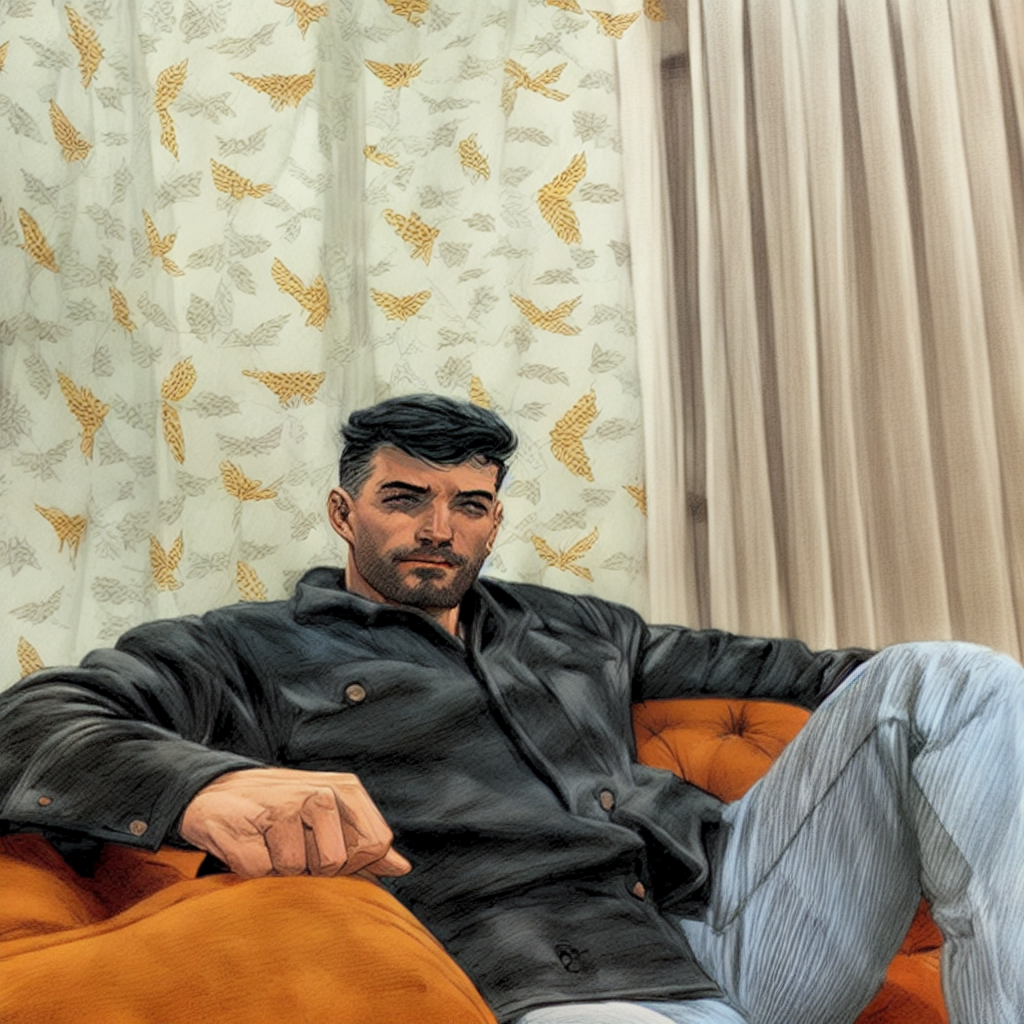

In [5]:
from PIL import Image, ImageOps, ImageDraw
from controlnet_aux import OpenposeDetector
import cv2
from IPython.display import display
import random
import numpy as np
from tqdm.auto import tqdm

def prepare_image(image, target_size=512, max_dim=768):
    """
    Prepares an image for processing: loads, ensures RGB, 
    FORCES RESIZE to target_size x target_size, ignoring aspect ratio.
    """
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
        
    image = ImageOps.exif_transpose(image) 
    
    image = image.convert("RGB") 
    
    original_width, original_height = image.size
    final_width = target_size 
    final_height = target_size 
    
    resized_image = image.resize((final_width, final_height), Image.LANCZOS) 
    
    print(f"Original size: ({original_width}, {original_height}), FORCED Resized to: ({final_width}, {final_height})")
    return resized_image

# --- Configuration & Paths ---
# input_image_path = "/kaggle/input/mystyletransferassets/1.jpg"
input_image_path = "/kaggle/input/mystyletransferassets/2.jpg"
# input_image_path = "/kaggle/input/mystyletransferassets/3.jpeg"
low_res_output_path = "/content/output_western_comic_lowres_512.png"
high_res_output_path = "/content/output_western_comic_tile_upscaled.png"
base_model_id = "runwayml/stable-diffusion-v1-5"

# --- Variables for holding results ---
output_image_low_res = None
high_res_output_image = None
control_image_openpose = None

# --- Check for Input Image ---
if not os.path.exists(input_image_path):
    print(f"Error: Input image not found at {input_image_path}")
else:
    # --- 1. Load and Prepare Input Image ---
    print(f"Loading input image from {input_image_path}")
    input_image_pil = load_image(input_image_path)
    input_image_resized = prepare_image(input_image_pil, target_size=512)

    # --- 2. Prepare OpenPose ControlNet Conditioning ---
    print("Preparing OpenPose conditioning image...")
    openpose_detector = None
    try:
        # Load detector
        openpose_detector = OpenposeDetector.from_pretrained('lllyasviel/ControlNet')
        openpose_detector.to('cuda:0')
        control_image_openpose = openpose_detector(input_image_resized, include_face=True, include_hand=True)
        openpose_detector.to('cpu')
        print("OpenPose detection complete.")
        control_image_openpose.save("/content/pose_map.png")
        print("Saved pose map to /content/pose_map.png")
    except Exception as e:
        print(f"Error during OpenPose detection: {e}")
        control_image_openpose = None
    finally:
        # Explicitly delete detector and clear cache
        if openpose_detector is not None: del openpose_detector
        gc.collect(); torch.cuda.empty_cache()
        print("Cleaned up OpenPose detector memory.")

# --- Proceed only if OpenPose map was created and initial pipe exists ---
if (control_image_openpose is not None and
    'pipe' in locals() and pipe is not None and
    'controlnet_tile' in locals() and controlnet_tile is not None):

    # --- 3. Define Prompts and Parameters for Initial Generation ---
    # --- Background Elements ---
    bg_settings = [
        "on a futuristic city street at night", "in a retro sci-fi control room", "in a dusty western saloon",
        "in front of an abstract energy field", "in a neon-lit alleyway", "in a stark cyberpunk cityscape",
        "with speed lines background", "in a manga panel frame", "in a dimly lit laboratory",
        "against a dramatic explosive background", "in a cluttered artist studio", "in a dynamic action scene"
    ]
    bg_details = [
        "detailed background", "cinematic lighting", "dramatic shadows",
        "high contrast", "low angle shot", "dynamic composition", "atmospheric perspective", "intricate details"
    ]
    chosen_bg_setting = random.choice(bg_settings)
    chosen_bg_detail_1 = random.choice(bg_details)
    # chosen_bg_detail_2 = random.choice(bg_details)
    # while chosen_bg_detail_1 == chosen_bg_detail_2:
    #      chosen_bg_detail_2 = random.choice(bg_details)
    # background_prompt = f"{chosen_bg_setting}, {chosen_bg_detail_1}, {chosen_bg_detail_2}"
    background_prompt = f"{chosen_bg_setting}, {chosen_bg_detail_1}"
    base_prompt = "detailed face portrait, accurate facial features, natural features, clear eyes, keep the gender same as the input image"
    style_prompt = "((LIMITED PALETTE)), ((RETRO COMIC)), ((1940S \(STYLE\))), ((WESTERN COMICS \(STYLE\))), ((NIGHT COMIC)), detailed illustration, sharp lines, sfw"
    positive_prompt = f"{base_prompt}, {style_prompt}, {background_prompt}"
    print(f"Using generated Positive Prompt for initial generation: {positive_prompt}")
    negative_prompt = (
        "generic face, distorted features, unrealistic face, bad anatomy, extra limbs, fused fingers, "
        "photorealistic, photo, blurry, deformed, text, signature, watermark, multiple panels, speech bubble, "
        "ugly, disfigured, low quality, worst quality, weapon, gun, knife, violence, gore, blood, "
        "injury, mutilated, horrific, nsfw, nude, naked, explicit, sexual, lingerie, bikini, suggestive, provocative, "
        "disturbing, scary, offensive, illegal, unlawful"
    )

    # Initial Generation Parameters
    num_inference_steps_gen = 1000
    guidance_scale_gen = 8
    controlnet_conditioning_scale_openpose = 1.0
    strength_gen = 0.05
    generator_seed = 1024
    active_adapters = ["style", "detail"]
    adapter_weights = [1, 1]

    print(f"\n--- Starting Initial Generation (Seed: {generator_seed}) on GPU 0 ---")
    pipe.to('cuda:0')
    generator_gen = torch.Generator(device="cuda:0").manual_seed(generator_seed)
    try:
        print(f"Setting active adapters: {active_adapters} with weights: {adapter_weights}")
        if 'lora_files_to_load' in locals() and 'loaded_adapter_names' in locals():
             pipe.set_adapters(active_adapters, adapter_weights=adapter_weights)
        else:
             print("Warning: LoRA info not found, running initial generation without LoRAs.")

        output_image_low_res = pipe(
            prompt=positive_prompt,
            negative_prompt=negative_prompt,
            image=input_image_resized,
            control_image=control_image_openpose,
            num_inference_steps=num_inference_steps_gen,
            strength=strength_gen,
            guidance_scale=guidance_scale_gen,
            controlnet_conditioning_scale=controlnet_conditioning_scale_openpose,
            generator=generator_gen,
        ).images[0]
        print("Initial image generation complete!")
        output_image_low_res.save(low_res_output_path)
        print(f"Low-res image saved to {low_res_output_path}")

    except Exception as e:
        print(f"Error during generation pipeline inference: {e}")
        output_image_low_res = None
    finally:
        # --- Cleanup Initial Generation Pipe ---
        print("Moving main generation pipeline (OpenPose) to CPU before deleting...")
        if 'pipe' in locals() and pipe is not None:
            try:
                pipe.to('cpu')
                print("Main pipe moved to CPU.")
            except Exception as cpu_move_error:
                print(f"Note: Could not move main pipe to CPU: {cpu_move_error}")
            print("Deleting main generation pipeline object...")
            del pipe
            pipe = None
        else:
            print("Main generation pipeline 'pipe' not found or already deleted.")

        print("Running garbage collection and emptying CUDA cache...")
        gc.collect()
        torch.cuda.empty_cache()
        print("Main generation pipeline resources released.")
        time.sleep(2) # Short pause


    # --- 5. Run ControlNet Tile Upscaling only if Generation Succeeded ---
    if output_image_low_res is not None:
        print("\n--- Starting ControlNet Tile Upscaling ---")

        # --- Parameters for Tiling ---
        upscale_factor = 2
        target_width = output_image_low_res.width * upscale_factor
        target_height = output_image_low_res.height * upscale_factor
        tile_size = 1024
        tile_stride = 1024
        overlap = tile_size - tile_stride

        # --- ADJUSTED TILE PARAMETERS for QUALITY ---
        positive_prompt_tile = f"{base_prompt}, {style_prompt}"
        negative_prompt_tile = (
            negative_prompt +
            # --- Tile-specific artifacts ---
            ", blurry, low quality, fuzzy, unclear details"
            ", seams, visible tile lines, grid lines, patchwork"
            ", pattern repetition, repeating elements"
            ", blurry face, distorted face, mangled face, malformed face, mutated face, bad face anatomy"
            ", photorealistic, photograph, realistic, smooth shading, soft lighting, 3D render"
        )
        num_inference_steps_tile = 20
        guidance_scale_tile = 8.0
        strength_tile = 0.75
        controlnet_conditioning_scale_tile = 1.0

        # --- Prepare Tile Pipeline ---
        pipe_tile = None
        try:
            print("Loading pipeline for Tiling...")
            controlnet_tile.to('cpu')
            
            # Load the Img2Img pipeline with the TILE ControlNet model
            pipe_tile = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
                base_model_id,
                controlnet=controlnet_tile,
                torch_dtype=torch.float16,
                safety_checker=None,
             )
            pipe_tile.scheduler = UniPCMultistepScheduler.from_config(pipe_tile.scheduler.config)

            # --- Move Tile pipeline to GPU 1 ---
            print("Moving Tile pipeline to cuda:1...")
            pipe_tile.to('cuda:1')

            # --- Apply LoRAs to the Tile Pipeline ---
            if 'lora_files_to_load' in locals() and 'loaded_adapter_names' in locals() and loaded_adapter_names:
                print(f"Applying LoRAs {loaded_adapter_names} to Tile pipeline...")
                for name in loaded_adapter_names:
                     pipe_tile.load_lora_weights(lora_files_to_load[name], adapter_name=name)
                pipe_tile.set_adapters(active_adapters, adapter_weights=[1, 2])
                print("LoRAs applied to Tile pipeline.")
            else:
                print("LoRA info not found, skipping application to Tile pipeline.")

            # --- Enable Memory Saving Features ---
            # pipe_tile.enable_attention_slicing()
            # pipe_tile.enable_vae_slicing()

            # --- Create Blurry Base Image for Tiling ---
            print(f"Creating blurry base image at {target_width}x{target_height}...")
            blurry_high_res = output_image_low_res.resize((target_width, target_height), Image.LANCZOS)
            blurry_high_res.save("/content/blurry_base_2x.png")

            # --- Prepare Canvas and Blend Mask ---
            final_image = Image.new("RGB", (target_width, target_height))
            blend_mask = Image.new("L", (tile_size, tile_size), 0)
            draw = ImageDraw.Draw(blend_mask)
            
            # Create a linear gradient for blending in the overlap area
            if overlap > 0:
               for i in range(overlap):
                    alpha = int(255 * (i / overlap))
                    # Blend left/right edges
                    draw.line([(i, 0), (i, tile_size)], fill=alpha)
                    draw.line([(tile_size - 1 - i, 0), (tile_size - 1 - i, tile_size)], fill=alpha)
                    # Blend top/bottom edges
                    draw.line([(0, i), (tile_size, i)], fill=alpha)
                    draw.line([(0, tile_size - 1 - i), (tile_size, tile_size - 1 - i)], fill=alpha)
            center_start = overlap // 2
            center_end_x = tile_size - overlap // 2
            center_end_y = tile_size - overlap // 2
            draw.rectangle( (center_start, center_start, center_end_x, center_end_y), fill=255 )
            # blend_mask.save("/content/blend_mask.png") # save mask for debugging


            # --- Tiling Loop ---
            print("Starting tile processing...")
            num_tiles_x = (target_width + tile_stride - 1) // tile_stride
            num_tiles_y = (target_height + tile_stride - 1) // tile_stride
            total_tiles = num_tiles_x * num_tiles_y
            print(f"Target Resolution: {target_width}x{target_height}, Tiles: {num_tiles_x}x{num_tiles_y} = {total_tiles}")
            processed_tiles = 0
            
            generator_tile = torch.Generator(device="cuda:1").manual_seed(generator_seed) 

            with tqdm(total=total_tiles, desc="Processing Tiles") as pbar:
                for y in range(num_tiles_y):
                    for x in range(num_tiles_x):
                        x_start = x * tile_stride
                        y_start = y * tile_stride
                        
                        tile_crop_box = (
                            max(0, x_start),
                            max(0, y_start),
                            min(target_width, x_start + tile_size),
                            min(target_height, y_start + tile_size)
                        )
                        tile_image_blurry = blurry_high_res.crop(tile_crop_box)

                        current_tile_width, current_tile_height = tile_image_blurry.size
                        if current_tile_width < tile_size or current_tile_height < tile_size:
                           try:
                               edge_color = tile_image_blurry.getpixel((0, 0)) 
                           except IndexError:
                               edge_color = (127, 127, 127)
    
                           padded_tile = Image.new("RGB", (tile_size, tile_size), edge_color)
                           padded_tile.paste(tile_image_blurry, (0,0))
                           tile_image_blurry = padded_tile

                        # --- Prepare inputs for the tile pipeline ---
                        init_image_tile = tile_image_blurry
                        control_image_tile = tile_image_blurry

                        # --- Run Inference on the Tile ---
                        with torch.inference_mode():
                            output_tile = pipe_tile(
                                prompt=positive_prompt_tile,
                                negative_prompt=negative_prompt_tile,
                                image=init_image_tile,
                                control_image=control_image_tile,
                                num_inference_steps=num_inference_steps_tile,
                                strength=strength_tile,
                                guidance_scale=guidance_scale_tile,
                                controlnet_conditioning_scale=controlnet_conditioning_scale_tile,
                                generator=generator_tile,
                                output_type = "pil"
                            ).images[0]

                        # --- Stitch the Processed Tile back onto the Canvas ---
                        paste_x = max(0, x_start)
                        paste_y = max(0, y_start)

                        # --- Alpha Blending for smoother transitions ---
                        crop_w = min(tile_size, target_width - paste_x)
                        crop_h = min(tile_size, target_height - paste_y)
                        current_content_region = final_image.crop((paste_x, paste_y, paste_x + crop_w, paste_y + crop_h))

                        # Prepare the output tile and mask for the actual size being pasted
                        output_tile_region = output_tile.crop((0, 0, crop_w, crop_h))
                        blend_mask_region = blend_mask.crop((0, 0, crop_w, crop_h))

                        # Blend the new tile region with the existing content using the mask
                        blended_tile_region = Image.composite(output_tile_region, current_content_region, blend_mask_region)
                        
                        # Paste the blended region back
                        final_image.paste(blended_tile_region, (paste_x, paste_y))

                        processed_tiles += 1
                        pbar.update(1)

            print("\nTile processing complete!")
            high_res_output_image = final_image
            high_res_output_image.save(high_res_output_path)
            print(f"High-res tiled image saved to {high_res_output_path}")

        except Exception as e:
            print(f"\n--- Error during ControlNet Tile upscaling ---")
            import traceback
            traceback.print_exc()
            high_res_output_image = None
        finally:
            # --- Cleanup Tile Pipeline ---
            print("Moving Tile pipeline back to CPU...")
            if 'pipe_tile' in locals() and pipe_tile is not None:
                try:
                    pipe_tile.to('cpu')
                except Exception as cpu_move_error:
                     print(f"Note: Could not move tile pipe to CPU: {cpu_move_error}")
                print("Deleting Tile pipeline object...")
                del pipe_tile
                pipe_tile = None
            print("Running garbage collection and emptying CUDA cache after Tiling...")
            gc.collect()
            torch.cuda.empty_cache()
            print("Tile pipeline resources released.")
            
    else:
        print("\nSkipping Tiling Upscaling because initial generation failed or produced no image.")

# --- 6. Display Final Result ---
print("\n--- Final Result ---")
if high_res_output_image is not None:
    print(f"Displaying final tiled high-res image ({high_res_output_image.width}x{high_res_output_image.height}):")
    display(high_res_output_image)
elif output_image_low_res is not None:
    print("\nTile upscaling failed or was skipped. Displaying low-res image as fallback:")
    display(output_image_low_res)
else:
    print("\nInitial generation failed or was skipped. No image to display.")